# Solute transport: mPCN vs pCN convergence

Generate a shared-draws solute-transport dataset and compare mPCN and pCN chains for convergence.
Chains are cached under estimations/solute_transport/... and figures are written to reports/solute_transport/... so reruns reuse existing chains.

In [1]:
import os
import sys
from pathlib import Path
import json
import hashlib

import numpy as np
import matplotlib.pyplot as plt

def _resolve_repo_root():
    env_root = os.environ.get("MULTIPROPOSAL_RUN_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()
    root = Path.cwd().resolve()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent
    return root

repo_root = _resolve_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
 )
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.utils.run_paths import format_float_tag
from multiproposal.plotting.figure_style import apply_pub_style

In [2]:
# Solute transport configuration
seed_data = 0
seed_mcmc = 202

# Select among predefined configurations (extend as needed)
config_id = 2  # 1=small, 2=medium, 3=extra_large, 4=baseline

configurations = {
    1: {"d": 20, "obs_highest_freq": 8, "obs_bandwidth": 5},
    2: {"d": 40, "obs_highest_freq": 12, "obs_bandwidth": 7},
    3: {"d": 60, "obs_highest_freq": 16, "obs_bandwidth": 9},
    4: {"d": 40, "obs_highest_freq": 8, "obs_bandwidth": 5},
}
if config_id not in configurations:
    raise ValueError(f"Unknown config_id: {config_id}")

selected_config = configurations[config_id]
d = selected_config["d"]
obs_highest_freq = selected_config["obs_highest_freq"]
obs_bandwidth = selected_config["obs_bandwidth"]

kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data
obs_config = 'central_modes'

print('config_id:', config_id)
print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

config_id: 2
d: 40
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [3]:
if isinstance(obs_config, dict):
    obs_config_serializable = {
        key: (val.tolist() if isinstance(val, np.ndarray) else val)
        for key, val in obs_config.items()
    }
else:
    obs_config_serializable = obs_config

data_id_config = {
    'seed_data': seed_data,
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'shared_draws_seed': shared_draws_seed,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'obs_config': obs_config_serializable,
    'd': d,
}
data_config = dict(data_id_config)
data_config

{'seed_data': 0,
 'kappa': 0.02,
 'sigma': 0.5,
 'alpha': 3.0,
 'gamma': 2.0,
 'tau2': 2.0,
 'a_mode': 'nearest_neighbor',
 'use_prior_A': True,
 'shared_draws_seed': 0,
 'obs_highest_freq': 12,
 'obs_bandwidth': 7,
 'obs_config': 'central_modes',
 'd': 40}

In [4]:
def _canonicalize_payload(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {key: _canonicalize_payload(val) for key, val in sorted(obj.items())}
    if isinstance(obj, (list, tuple)):
        return [_canonicalize_payload(val) for val in obj]
    return obj

def _stable_hash(payload, length=12):
    data = json.dumps(
        _canonicalize_payload(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    ).encode("utf-8")
    return hashlib.sha256(data).hexdigest()[:length]

In [5]:
# Shared-draws helpers
def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)

def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]

def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(
            f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}'
        )
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(
            d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset
        )
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }

def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }

def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [6]:
shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
)
problem, a_init, data = build_problem_for_dim(d, shared_draws)
prior_diag = data['prior_diag']

print('Shared draws ready with d:', d)
print('Parameter dim:', problem.dim)
print('Initial x0 norm:', np.linalg.norm(a_init))

Shared draws ready with d: 40
Parameter dim: 780
Initial x0 norm: 0.33344310180534587


In [7]:
# MCMC configuration
n_iters = 100000
rho = 0.9
P = 100
num_pcn_chains = 100
num_mpcn_chains = 50
burn_in = 0

load_only = True

print('n_iters:', n_iters)
print('rho:', rho)
print('P:', P)
print('num_pcn_chains:', num_pcn_chains)
print('num_mpcn_chains:', num_mpcn_chains)
print('load_only:', load_only)

n_iters: 100000
rho: 0.9
P: 100
num_pcn_chains: 100
num_mpcn_chains: 50
load_only: True


In [8]:
run_config = {
    'dataset': 'solute_transport',
    'algorithm': 'mpcn_pcn_convergence',
    'data': data_config,
    'algorithm_config': {
        'n_iters': n_iters,
        'rho': rho,
        'P': P,
        'seed_mcmc': seed_mcmc,
        'burn_in': burn_in,
        'config_id': config_id,
    },
    'execution_config': {
        'num_pcn_chains': num_pcn_chains,
        'num_mpcn_chains': num_mpcn_chains,
    },
}
# Leave overrides as None to ensure new data/run folders per config.
data_id_override = None
run_id_override = None

run_id_config = dict(run_config['algorithm_config'])
data_id = data_id_override or f"data_h{_stable_hash(data_id_config)}"
run_id = run_id_override or f"mpcn_pcn_convergence_h{_stable_hash(run_id_config)}"

estimations_dir = repo_root / 'estimations' / 'solute_transport' / data_id / 'fixed' / run_id
reports_dir = repo_root / 'reports' / 'solute_transport' / data_id / 'fixed' / run_id
estimations_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

config_path = estimations_dir / 'config.json'
if not config_path.exists():
    payload = dict(run_config)
    payload['data_id'] = data_id
    payload['run_id'] = run_id
    with open(config_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

print('data_id:', data_id)
print('run_id:', run_id)
print('Run directory:', estimations_dir)

data_id: data_h4afe80f670cc
run_id: mpcn_pcn_convergence_h57eaaa0da6e8
Run directory: /home/senng/multiproposal-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8


In [9]:
rho_tag = format_float_tag(rho)
pcn_chains_dir = estimations_dir / 'chains' / 'independent_chains'
mpcn_chains_dir = estimations_dir / 'chains' / 'mpcn_independent'
pcn_chains_dir.mkdir(parents=True, exist_ok=True)
mpcn_chains_dir.mkdir(parents=True, exist_ok=True)

def pcn_chain_path(chain_idx):
    return pcn_chains_dir / f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_chain{chain_idx:03d}.npz'

def pcn_index_path():
    return pcn_chains_dir / f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_index.json'

def mpcn_chain_path(chain_idx, seed):
    return mpcn_chains_dir / f'mpcn_P{P}_rho{rho_tag}_seed{seed}_chain{chain_idx:03d}.npz'

def mpcn_index_path():
    return mpcn_chains_dir / f'mpcn_P{P}_rho{rho_tag}_seed{seed_mcmc}_index.json'

def load_index(path):
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as handle:
        return json.load(handle)

def load_chain(path):
    if not path.exists():
        return None
    data = np.load(path, allow_pickle=True)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    return chain, accept_rate, runtime_sec

def _indices_from_index(index_path, max_count):
    payload = load_index(index_path)
    if not payload:
        return []
    indices = []
    for entry in payload.get('chains', []):
        idx = entry.get('chain_idx')
        if isinstance(idx, (int, np.integer)) and 0 <= int(idx) < max_count:
            indices.append(int(idx))
    return sorted(set(indices))

def _indices_from_glob(chains_dir, pattern, max_count):
    indices = []
    for path in sorted(chains_dir.glob(pattern)):
        stem = path.stem
        parts = stem.split('_chain')
        if len(parts) != 2:
            continue
        try:
            idx = int(parts[1])
        except ValueError:
            continue
        if 0 <= idx < max_count:
            indices.append(idx)
    return sorted(set(indices))

In [10]:
pcn_chain_indices = _indices_from_index(pcn_index_path(), num_pcn_chains)
if not pcn_chain_indices:
    pcn_chain_indices = _indices_from_glob(
        pcn_chains_dir,
        f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_chain*.npz',
        num_pcn_chains,
    )

pcn_chains = []
pcn_accept_rates = []
pcn_runtimes = []
pcn_loaded_count = 0

for chain_idx in pcn_chain_indices:
    loaded = load_chain(pcn_chain_path(chain_idx))
    if loaded is None:
        continue
    chain, acc_rate, runtime_sec = loaded
    pcn_chains.append(chain)
    pcn_accept_rates.append(acc_rate)
    pcn_runtimes.append(runtime_sec)
    pcn_loaded_count += 1

if pcn_loaded_count == 0:
    print(f'No pCN chains found in {pcn_chains_dir}.')
else:
    print(f'Loaded {pcn_loaded_count} of {num_pcn_chains} pCN chains.')

Loaded 100 of 100 pCN chains.


In [11]:
mpcn_chain_indices = _indices_from_index(mpcn_index_path(), num_mpcn_chains)
if not mpcn_chain_indices:
    mpcn_chain_indices = _indices_from_glob(
        mpcn_chains_dir,
        f'mpcn_P{P}_rho{rho_tag}_seed*_chain*.npz',
        num_mpcn_chains,
    )

mpcn_chains = []
mpcn_accept_rates = []
mpcn_runtimes = []
mpcn_loaded_count = 0

for chain_idx in mpcn_chain_indices:
    seed = seed_mcmc + 5000 + chain_idx
    loaded = load_chain(mpcn_chain_path(chain_idx, seed))
    if loaded is None:
        continue
    chain, acc_rate, runtime_sec = loaded
    mpcn_chains.append(chain)
    mpcn_accept_rates.append(acc_rate)
    mpcn_runtimes.append(runtime_sec)
    mpcn_loaded_count += 1

if mpcn_loaded_count == 0:
    print(f'No mPCN chains found in {mpcn_chains_dir}.')
else:
    print(f'Loaded {mpcn_loaded_count} of {num_mpcn_chains} mPCN chains.')

Loaded 50 of 50 mPCN chains.


## MSE setup: chain loading and observables

Load trimmed chains, EP replicates, and cached observable targets used by the running-MSE section.

## Observable ID map

Use these IDs to populate `trace_observable_ids` and `mse_observable_ids`.

**Parameter observables**
1. $\bar{x}_{1:d-1}$ (FirstRowMean)
2. $\mathrm{Var}(x_{1:d-1})$ (FirstRowVar)
3. $x_0$ (FirstComponent)
4. $\min_i x_i$ (Min)
5. $\bar{x}=\frac{1}{d}\sum_i x_i$ (Mean)
6. $\mathrm{Var}(x)$ (Variance)
7. $\|x\|_2$ (Norm)
8. $\Phi(x)=\frac{1}{2\sigma^2}\|y-f(x)\|^2$ (Potential)

**Antisymmetric matrix $A$ observables**
101. $E_k(A)$ (BandEnergy)
102. $\max_{i<j}|a_{ij}|$ (MaxEntry)
103. $T_k(A)$ (TopKAvg)
104. $\|A\|_2$ (SpectralNorm; skipped)
105. $S_\varepsilon(A)$ (Support)
106. $R_i(A)$ (RowNorm; set `row_index` or `row_indices`)

In [12]:
# MSE setup: imports and knobs
from pathlib import Path
import gc

from multiproposal.diagnostics.observables import (
    Observable,
    make_parameter_observables,
    make_antisymmetric_A_observables,
    select_observables,
    compute_observable_targets,
 )

true_values = data.get('a_true', None)
if true_values is None:
    raise ValueError('Missing true parameter values in data.')

# Limit per-chain samples to reduce memory; set to None to load full chains.
chain_keep = 20000
burnin_true_mean = 5000
recompute_true_observables = False

# A-observable hyperparameters
A_band_k = 2
A_top_k = 5
A_support_eps = 0.001
A_row_index = 0
A_use_full_row = False

# Plot selection by observable ID; set to None to plot all.
# Example: [1, 2, 5, 101, 105, 106]
trace_observable_ids = None
mse_observable_ids = None

In [13]:
# MSE setup: chain loading helpers
def _load_chain_slice(path, n_keep):
    data = np.load(path, allow_pickle=False, mmap_mode='r')
    if 'chain' not in data:
        data.close()
        return None
    chain = data['chain']
    if n_keep is None:
        chain_out = np.array(chain)
    else:
        chain_out = np.array(chain[:n_keep])
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    data.close()
    return chain_out, accept_rate, runtime_sec

def _load_pcn_replicate_chains(rep_dirs, pattern, n_keep):
    chains = []
    for rep_dir in rep_dirs:
        for path in sorted(rep_dir.glob(pattern)):
            loaded = _load_chain_slice(path, n_keep)
            if loaded is None:
                continue
            chain, _, _ = loaded
            chains.append(chain)
    return chains

def _ensure_mpcn_trimmed_chains(
    source_dir,
    target_dir,
    pattern,
    max_chains=50,
    n_keep=20000,
    exclude_substrings=('_partial',),
):
    target_dir.mkdir(parents=True, exist_ok=True)
    source_paths = []
    for path in sorted(source_dir.glob(pattern)):
        if exclude_substrings and any(substr in path.name for substr in exclude_substrings):
            continue
        source_paths.append(path)
        if len(source_paths) >= max_chains:
            break
    if not source_paths:
        print(f'No source mPCN chains found in {source_dir}.')
        return 0
    created = 0
    for path in source_paths:
        target_path = target_dir / path.name
        if target_path.exists():
            continue
        data = np.load(path, allow_pickle=False, mmap_mode='r')
        if 'chain' not in data:
            data.close()
            continue
        chain = data['chain']
        if chain.shape[0] < n_keep:
            print(f'Warning: {path.name} shorter than {n_keep} samples.')
            chain_trim = np.array(chain)
        else:
            chain_trim = np.array(chain[:n_keep])
        accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
        runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
        np.savez_compressed(
            target_path,
            chain=chain_trim,
            accept_rate=accept_rate,
            runtime_sec=runtime_sec,
        )
        data.close()
        del chain_trim
        del chain
        del data
        gc.collect()
        created += 1
    if created:
        print(f'Created {created} trimmed mPCN chains in {target_dir}.')
    return created

def _load_chains_from_dir(
    chains_dir,
    pattern,
    max_chains=None,
    n_keep=None,
    exclude_substrings=('_partial',),
):
    chains = []
    for path in sorted(chains_dir.glob(pattern)):
        if exclude_substrings and any(substr in path.name for substr in exclude_substrings):
            continue
        loaded = _load_chain_slice(path, n_keep)
        if loaded is None:
            continue
        chain, _, _ = loaded
        chains.append(chain)
        if max_chains is not None and len(chains) >= max_chains:
            break
    return chains

In [14]:
# MSE setup: load pCN chains
pcn_pattern = f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_chain*.npz'

pcn_standard_root = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/'
    'chains/independent_chains'
 )
pcn_standard_max = 50  # Reduce memory; set to 100 if you want all chains.
pcn_chains_for_mse = _load_chains_from_dir(
    pcn_standard_root, pcn_pattern, max_chains=pcn_standard_max, n_keep=chain_keep
 )
if pcn_chains_for_mse:
    print(f'Loaded {len(pcn_chains_for_mse)} pCN chains for standard estimator.')
else:
    print(f'Warning: no pCN chains found in {pcn_standard_root}.')

pcn_ep_root = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_hc6f2f62899e7/'
    'chains/independent_chains'
 )
pcn_ep_replicate_dirs = sorted([
    path for path in pcn_ep_root.glob('replicate_*') if path.is_dir()
 ])
pcn_chains_for_ep = _load_pcn_replicate_chains(
    pcn_ep_replicate_dirs,
    pcn_pattern,
    chain_keep,
 )
if pcn_chains_for_ep:
    print(f'Loaded {len(pcn_chains_for_ep)} pCN replicate chains for EP estimator.')
else:
    print(f'Warning: no pCN replicate chains found in {pcn_ep_root}.')

Loaded 50 pCN chains for standard estimator.
Loaded 100 pCN replicate chains for EP estimator.


In [15]:
# MSE setup: load mPCN chains
mpcn_source_dir = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/'
    'chains/mpcn_independent'
 )
mpcn_target_dir = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_hc6f2f62899e7/'
    'chains/mpcn_independent'
 )
mpcn_pattern = f'mpcn_P{P}_rho{rho_tag}_seed*_chain*.npz'
_ensure_mpcn_trimmed_chains(
    mpcn_source_dir,
    mpcn_target_dir,
    mpcn_pattern,
    max_chains=50,
    n_keep=chain_keep,
 )

mpcn_chains_for_mse = _load_chains_from_dir(
    mpcn_target_dir,
    mpcn_pattern,
    max_chains=50,
    n_keep=chain_keep,
    exclude_substrings=('_partial',),
 )
if mpcn_chains_for_mse:
    print(f'Loaded {len(mpcn_chains_for_mse)} mPCN chains for MSE.')
if not mpcn_chains_for_mse or not pcn_chains_for_mse:
    print('Warning: missing chains for MSE computation.')

posterior_mean_chain_count = min(50, len(mpcn_chains_for_mse))

Loaded 50 mPCN chains for MSE.


In [16]:
# MSE setup: build observables and targets
parameter_observables = make_parameter_observables(problem, d)
A_observables_raw = make_antisymmetric_A_observables(
    k_band=A_band_k,
    top_k=A_top_k,
    eps=A_support_eps,
    row_index=A_row_index,
    full_row=A_use_full_row,
 )
A_observables_raw = [obs for obs in A_observables_raw if obs.obs_id != 104]

def _wrap_A_observables_for_params(a_observables, dim):
    wrapped = []
    for obs in a_observables:
        wrapped.append(
            Observable(
                obs.obs_id,
                obs.name,
                obs.label,
                lambda params, fn=obs.value_fn, dd=dim: fn(make_Astar_from_atrue(dd, params)),
            )
        )
    return wrapped

A_observables = _wrap_A_observables_for_params(A_observables_raw, d)
observable_defs = parameter_observables + A_observables
mse_observable_defs = observable_defs

if trace_observable_ids is None:
    trace_plot_defs = observable_defs
else:
    trace_plot_defs = select_observables(observable_defs, trace_observable_ids)
if mse_observable_ids is None:
    mse_plot_defs = mse_observable_defs
else:
    mse_plot_defs = select_observables(mse_observable_defs, mse_observable_ids)
if not trace_plot_defs:
    raise ValueError('No observables selected for traceplots.')
if not mse_plot_defs:
    raise ValueError('No observables selected for MSE plots.')

target_metrics_dir = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/metrics'
 )
target_metrics_dir.mkdir(parents=True, exist_ok=True)
target_metrics_path = target_metrics_dir / f'pub_observables_true_mean_rho{rho_tag}_burn{burnin_true_mean}.npz'

expected_ids = [obs.obs_id for obs in observable_defs]
expected_labels = [obs.label for obs in observable_defs]

true_obs_values = None
if target_metrics_path.exists() and not recompute_true_observables:
    saved = np.load(target_metrics_path)
    saved_vals = saved.get('true_obs_values')
    saved_ids = saved.get('observable_ids')
    if (
        saved_vals is not None
        and saved_ids is not None
        and [int(val) for val in saved_ids] == expected_ids
        and int(saved.get('burn_in', -1)) == int(burnin_true_mean)
    ):
        true_obs_values = [float(val) for val in saved_vals]
if true_obs_values is None:
    if chain_keep is not None and chain_keep <= burnin_true_mean:
        raise ValueError('chain_keep must exceed burnin_true_mean to recompute observables.')
    mpcn_target_use = _load_chains_from_dir(
        mpcn_source_dir,
        mpcn_pattern,
        max_chains=posterior_mean_chain_count,
        n_keep=chain_keep,
        exclude_substrings=('_partial',),
    )
    if not mpcn_target_use:
        raise ValueError('No mPCN chains available to compute true observables.')
    true_obs_values = compute_observable_targets(
        mpcn_target_use, observable_defs, burnin_true_mean
    )
    np.savez_compressed(
        target_metrics_path,
        true_obs_values=np.array(true_obs_values, dtype=float),
        observable_ids=np.array(expected_ids, dtype=int),
        observable_labels=np.array(expected_labels, dtype=object),
        burn_in=int(burnin_true_mean),
        chain_count=int(len(mpcn_target_use)),
    )

observable_targets = {
    obs.name: float(true_obs_values[idx])
    for idx, obs in enumerate(observable_defs)
}

## Traceplots

In [17]:
# # Traceplots: mPCN (top) vs pCN (bottom) for first 3 parameters
# apply_pub_style()

# comp_list = [0, 1, 2]
# comp_list = [idx for idx in comp_list if idx < problem.dim]
# if len(comp_list) < 1:
#     raise ValueError('Need at least one component for traceplots.')

# plot_n = min(n_iters, 1000)
# mpcn_plot_count = 10
# pcn_plot_count = 10
# row_height = 1.0

# mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
# pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

# mpcn_plot_indices = list(range(mpcn_plot_count))
# pcn_plot_indices = list(range(pcn_plot_count))

# trace_series = []
# for i in mpcn_plot_indices:
#     chain_idx = mpcn_chain_indices[i] if i < len(mpcn_chain_indices) else i
#     trace_series.append((f'mPCN chain {chain_idx + 1}', mpcn_chains[i]))
# for i in pcn_plot_indices:
#     chain_idx = pcn_chain_indices[i] if i < len(pcn_chain_indices) else i
#     trace_series.append((f'pCN chain {chain_idx + 1}', pcn_chains[i]))

# true_values = data.get('a_true', None)

# nrows = len(trace_series)
# ncols = len(comp_list)
# fig, axes = plt.subplots(
#     nrows,
#     ncols,
#     figsize=(4.2 * ncols, row_height * nrows),
#     sharex=True,
#     sharey='col',
# )
# if nrows == 1:
#     axes = np.array([axes])
# if ncols == 1:
#     axes = axes[:, None]

# for row_idx, (label, chain) in enumerate(trace_series):
#     post_chain = chain[:plot_n]
#     for col_idx, comp in enumerate(comp_list):
#         ax = axes[row_idx, col_idx]
#         ax.plot(post_chain[:, comp], linewidth=0.6, color='tab:blue')
#         if true_values is not None:
#             ax.axhline(
#                 true_values[comp],
#                 color='black',
#                 linestyle=':',
#                 linewidth=0.8,
#             )
#         if row_idx == 0:
#             ax.set_title(f'Component {comp}')
#         if col_idx == 0:
#             ax.set_ylabel(label, rotation=0, labelpad=40, va='center')
#         ax.grid(alpha=0.2)

# for ax in axes[-1, :]:
#     ax.set_xlabel('Iteration')

# fig.suptitle('Traceplots: mPCN (top) vs pCN (bottom)')
# fig.tight_layout()
# fig.savefig(
#     reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_rho{rho_tag}.png',
#     bbox_inches='tight',
# )
# plt.show()

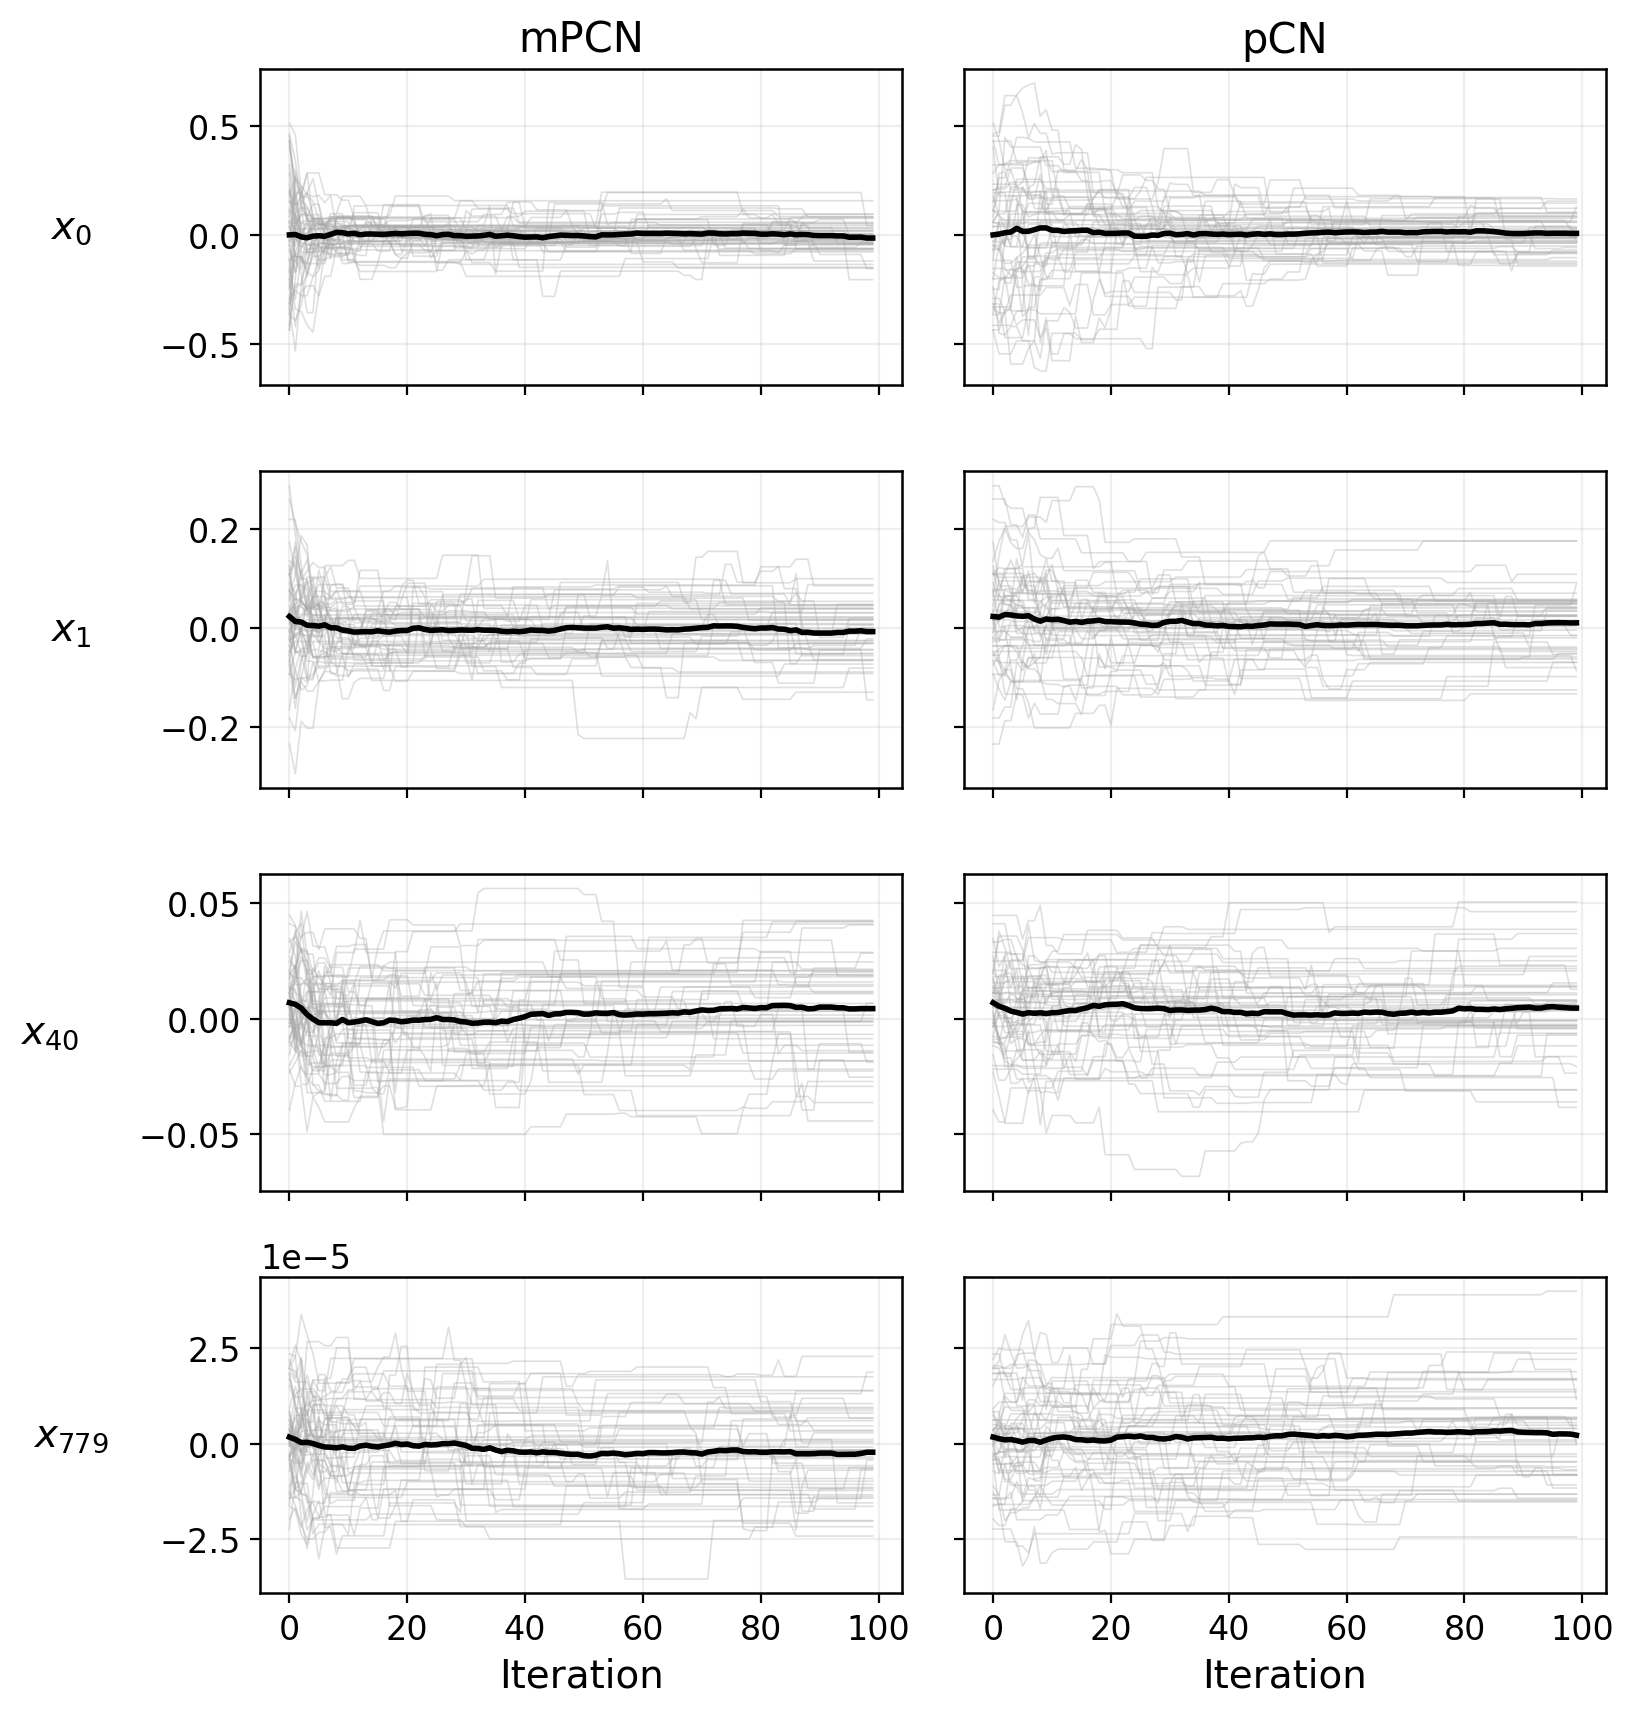

In [18]:
# Overlayed traceplots: all mPCN together and all pCN together (grouped by observable)
apply_pub_style()

comp_list = [0, 1, 40, 779]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 1:
    raise ValueError('Need at least one component for traceplots.')

plot_n = min(n_iters, 100)
mpcn_plot_count = 50
pcn_plot_count = 50
mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

mpcn_plot_indices = list(range(mpcn_plot_count))
pcn_plot_indices = list(range(pcn_plot_count))

mpcn_stack = np.stack([mpcn_chains[i][:plot_n] for i in mpcn_plot_indices], axis=0)
pcn_stack = np.stack([pcn_chains[i][:plot_n] for i in pcn_plot_indices], axis=0)
mpcn_mean = np.mean(mpcn_stack, axis=0)
pcn_mean = np.mean(pcn_stack, axis=0)

alg_defs = [
    ('mPCN', mpcn_stack, mpcn_mean),
    ('pCN', pcn_stack, pcn_mean),
]

chain_color = '0.65'
mean_color = '0.0'
chain_linewidth = 0.6
mean_linewidth = 2.0

nrows = len(comp_list)
ncols = 2
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(8.4, 2.2 * nrows),
    sharex=True,
    sharey='row',
)
if nrows == 1:
    axes = np.array([axes])

for row_idx, comp in enumerate(comp_list):
    obs_label = rf"$x_{{{comp}}}$"
    for col_idx, (label, stack, mean_chain) in enumerate(alg_defs):
        ax = axes[row_idx, col_idx]
        for chain_idx in range(stack.shape[0]):
            ax.plot(
                stack[chain_idx, :, comp],
                linewidth=chain_linewidth,
                color=chain_color,
                alpha=0.35,
            )
        ax.plot(mean_chain[:, comp], linewidth=mean_linewidth, color=mean_color)
        if col_idx == 0:
            ax.set_ylabel(obs_label, rotation=0, labelpad=32, va='center')
        ax.grid(alpha=0.2)

for col_idx, (label, _, _) in enumerate(alg_defs):
    axes[0, col_idx].set_title(label)

for ax in axes[-1, :]:
    ax.set_xlabel('Iteration')

fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_overlay_rho{rho_tag}.png',
    bbox_inches='tight',
)
plt.show()

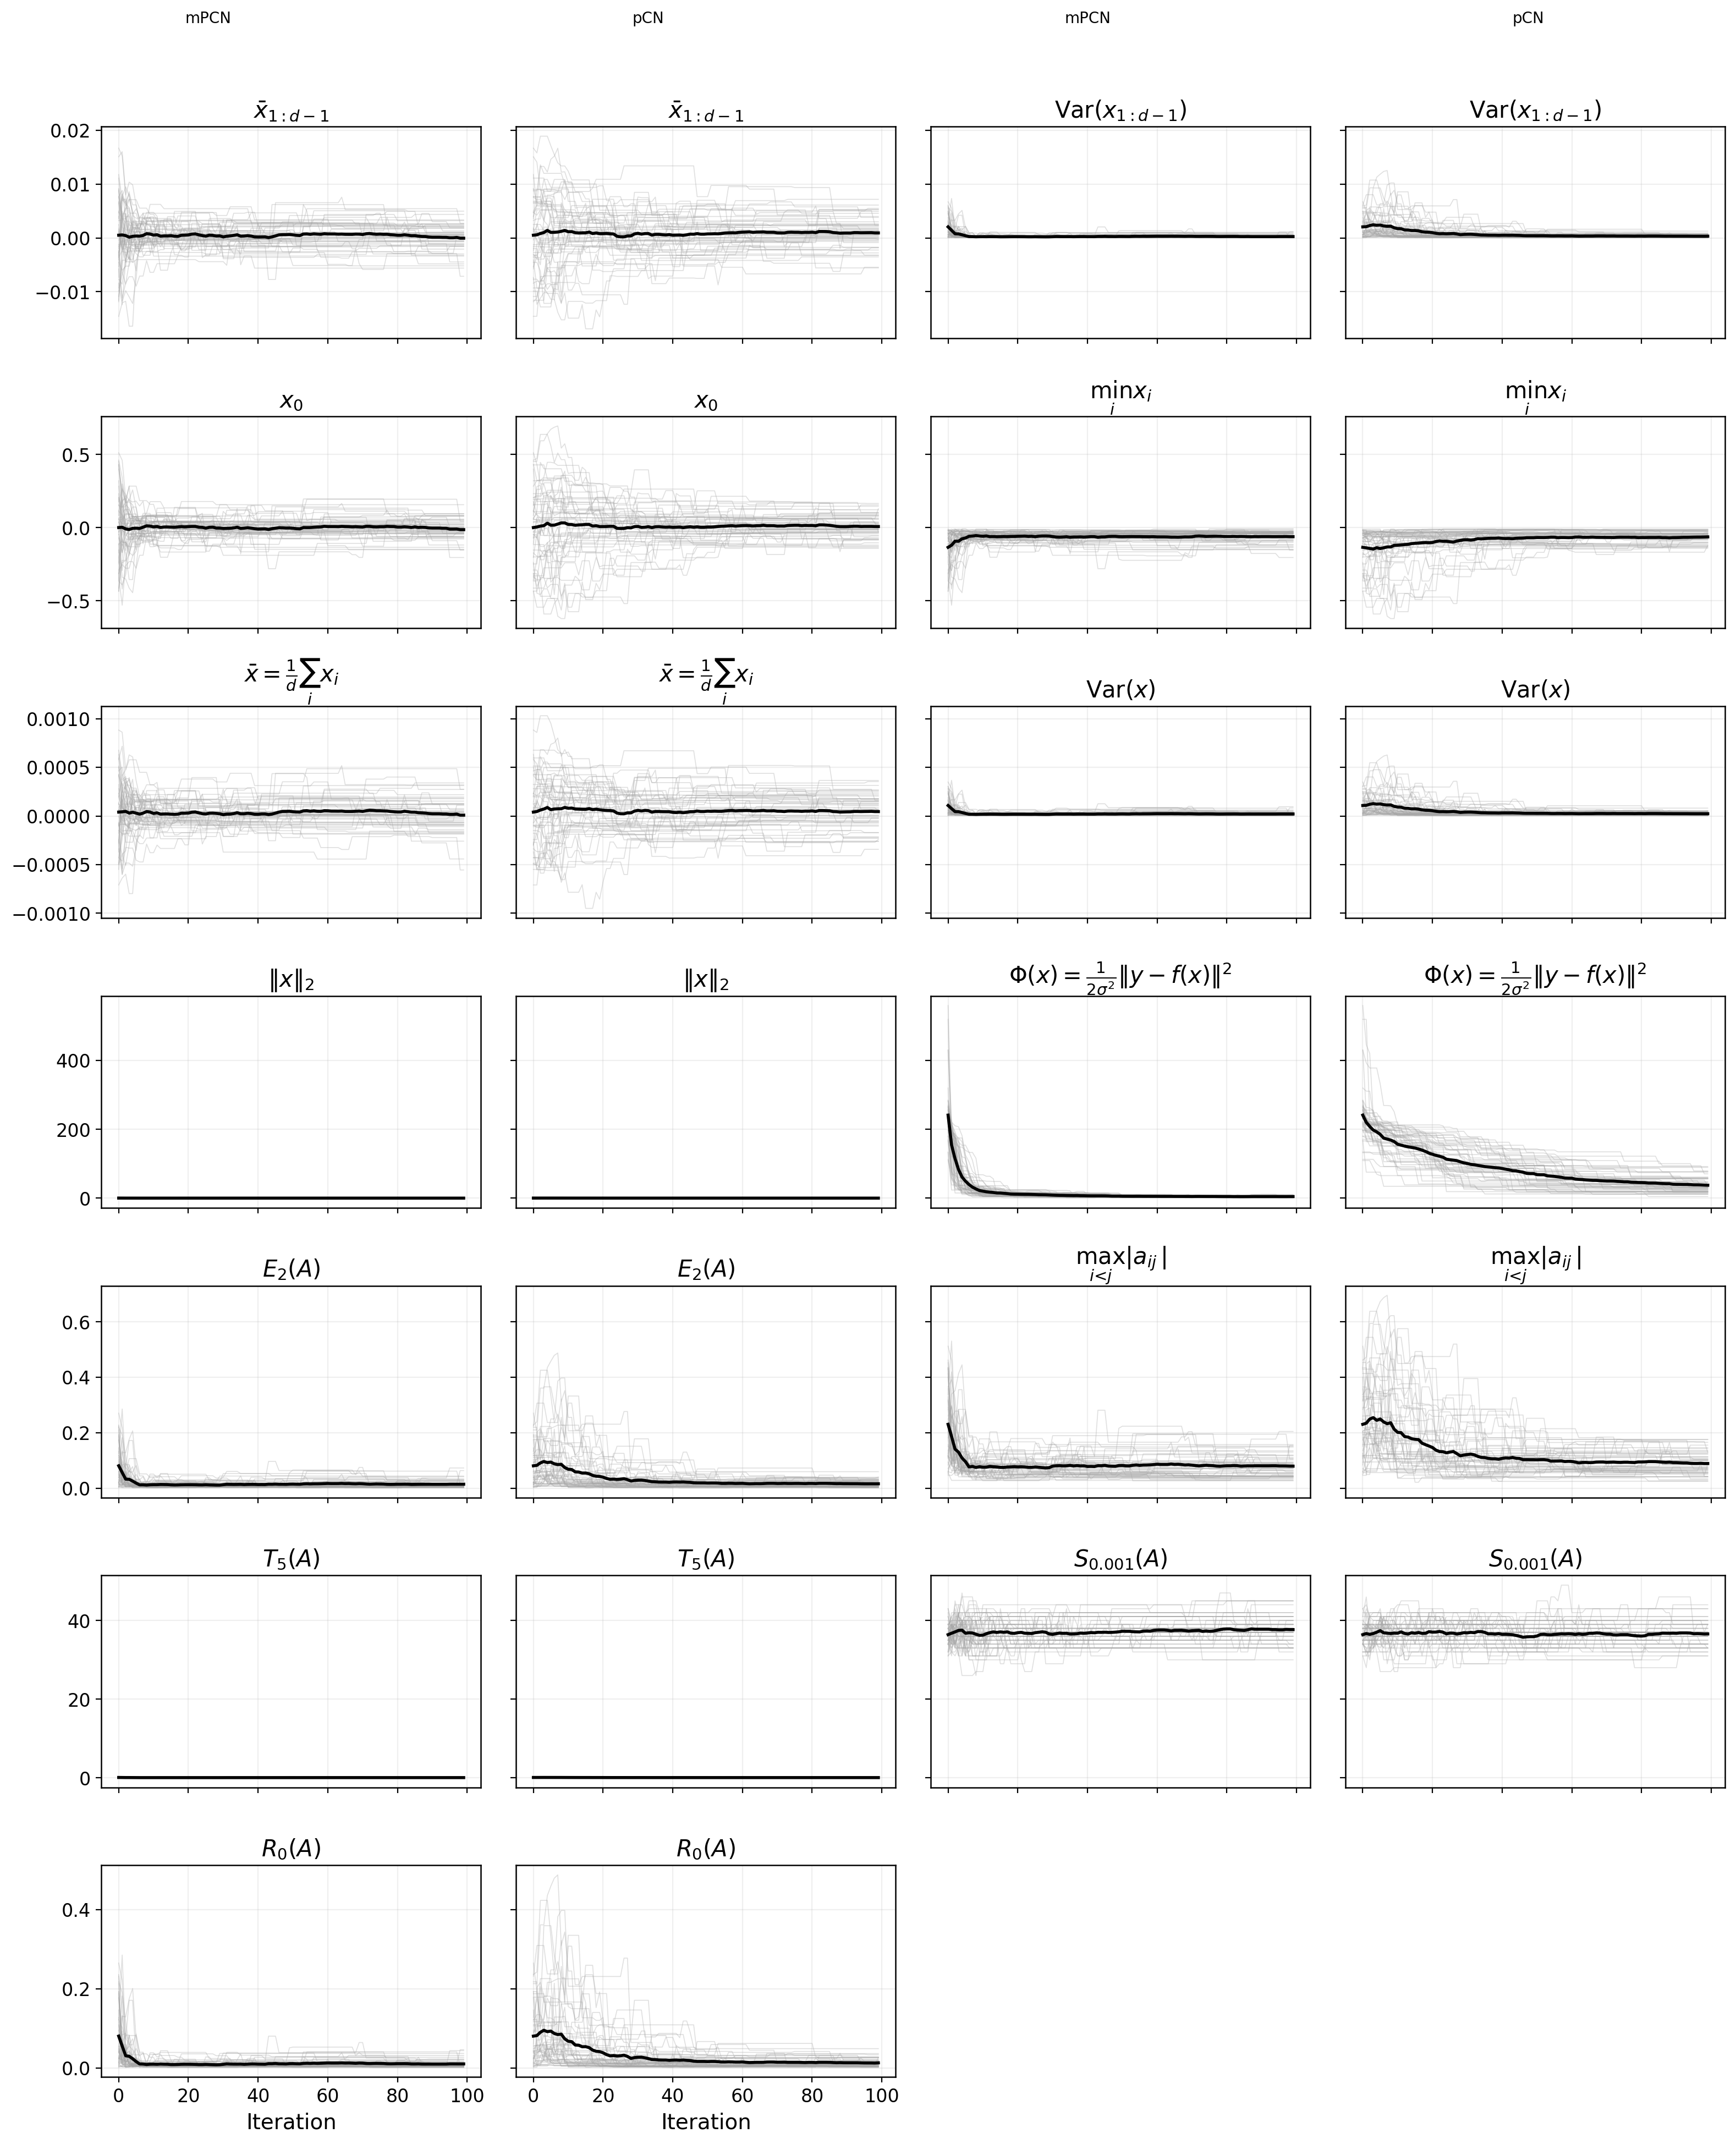

In [19]:
# Overlayed traceplots for additional observables
apply_pub_style()

from multiproposal.diagnostics.observables import stack_observable_series

plot_n = min(n_iters, 100)
mpcn_plot_count = 50
pcn_plot_count = 50
mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

mpcn_plot_indices = list(range(mpcn_plot_count))
pcn_plot_indices = list(range(pcn_plot_count))

mpcn_chains_plot = [mpcn_chains[i][:plot_n] for i in mpcn_plot_indices]
pcn_chains_plot = [pcn_chains[i][:plot_n] for i in pcn_plot_indices]

chain_color = '0.65'
mean_color = '0.0'
chain_linewidth = 0.6
mean_linewidth = 2.0

observables_to_plot = trace_plot_defs
if not observables_to_plot:
    raise ValueError('No observables selected for plotting.')

n_obs = len(observables_to_plot)
nrows = int(np.ceil(n_obs / 2))
fig, axes = plt.subplots(nrows, 4, figsize=(16.0, 2.8 * nrows), sharex=True, sharey='row')
if nrows == 1:
    axes = axes[None, :]

col_titles = ['mPCN', 'pCN', 'mPCN', 'pCN']
for col_idx, title in enumerate(col_titles):
    fig.text((col_idx + 0.5) / 4.0, 0.995, title, ha='center', va='top', fontsize=10)

for obs_idx, obs in enumerate(observables_to_plot):
    row_idx = obs_idx // 2
    block_idx = obs_idx % 2
    col0 = block_idx * 2
    col1 = col0 + 1

    mpcn_obs = stack_observable_series(mpcn_chains_plot, obs)
    pcn_obs = stack_observable_series(pcn_chains_plot, obs)
    mpcn_mean = np.mean(mpcn_obs, axis=0)
    pcn_mean = np.mean(pcn_obs, axis=0)

    ax_m = axes[row_idx, col0]
    ax_p = axes[row_idx, col1]

    for chain_idx in range(mpcn_obs.shape[0]):
        ax_m.plot(
            mpcn_obs[chain_idx],
            linewidth=chain_linewidth,
            color=chain_color,
            alpha=0.35,
        )
    ax_m.plot(mpcn_mean, linewidth=mean_linewidth, color=mean_color)
    ax_m.set_title(obs.label)
    ax_m.grid(alpha=0.2)

    for chain_idx in range(pcn_obs.shape[0]):
        ax_p.plot(
            pcn_obs[chain_idx],
            linewidth=chain_linewidth,
            color=chain_color,
            alpha=0.35,
        )
    ax_p.plot(pcn_mean, linewidth=mean_linewidth, color=mean_color)
    ax_p.set_title(obs.label)
    ax_p.grid(alpha=0.2)

if n_obs % 2 == 1:
    for ax in axes[-1, 2:4]:
        ax.set_visible(False)

for ax in axes[-1, :]:
    if ax.get_visible():
        ax.set_xlabel('Iteration')

fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.965))
fig.savefig(
    reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_observables_rho{rho_tag}.png',
    bbox_inches='tight',
)
plt.show()

/tmp/ipykernel_175723/4294271456.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))


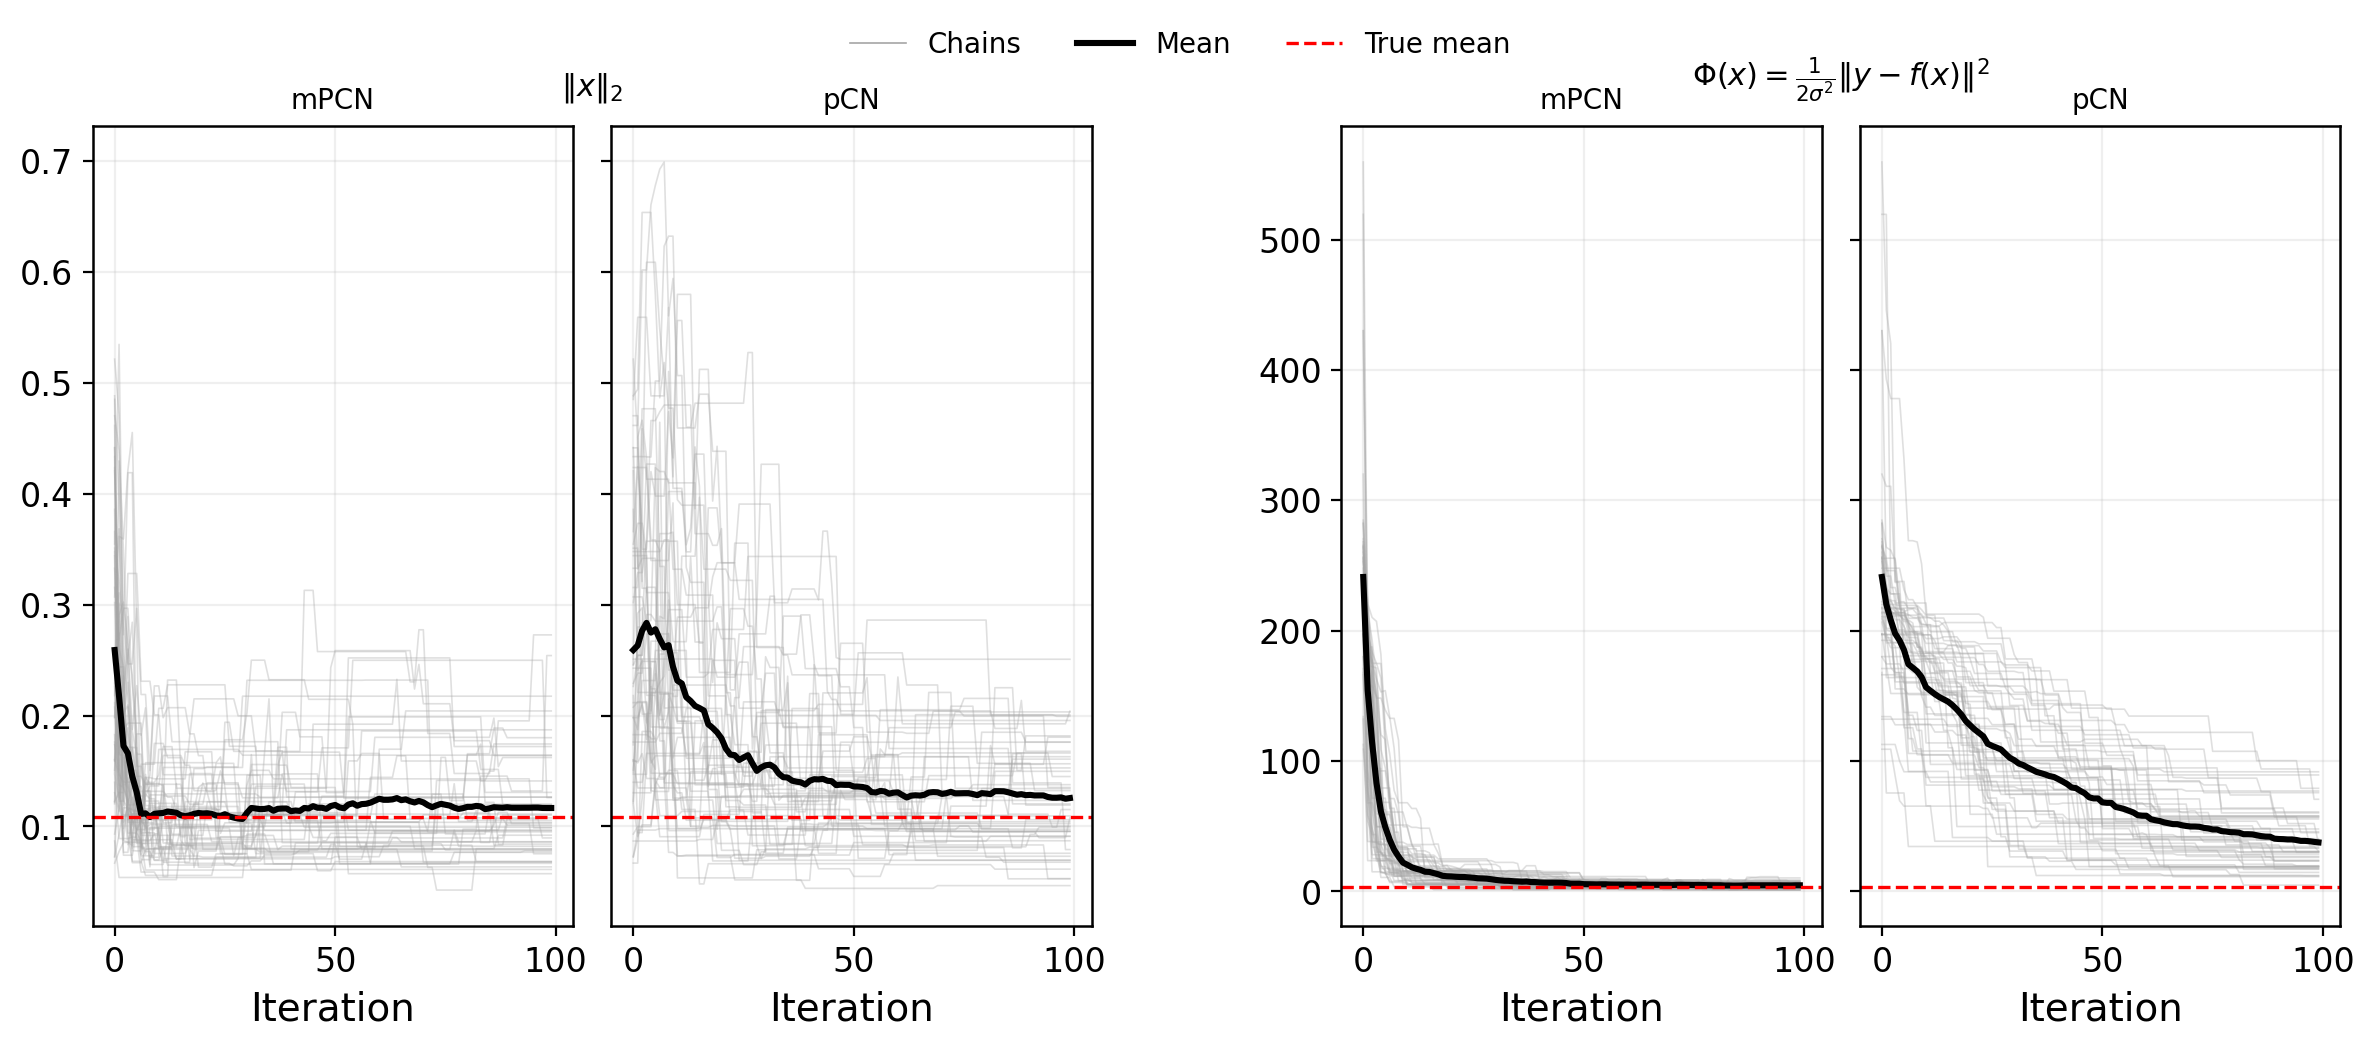

In [22]:
# Publication-quality observables: mean, variance, norm, potential
apply_pub_style()

from matplotlib.lines import Line2D
from multiproposal.diagnostics.observables import (
    make_parameter_observables,
    select_observables,
    stack_observable_series,
    compute_observable_targets,
 )

plot_n = min(n_iters, 100)
mpcn_plot_count = 50
pcn_plot_count = 50
mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

mpcn_plot_indices = list(range(mpcn_plot_count))
pcn_plot_indices = list(range(pcn_plot_count))

mpcn_chains_plot = [mpcn_chains[i][:plot_n] for i in mpcn_plot_indices]
pcn_chains_plot = [pcn_chains[i][:plot_n] for i in pcn_plot_indices]

chain_color = '0.65'
mean_color = '0.0'
chain_linewidth = 0.6
mean_linewidth = 2.2
true_line_color = 'red'
true_line_style = '--'
true_line_width = 1.2

observables_all = make_parameter_observables(problem, d)
pub_plot_observable_ids = [7, 8, 101]
pub_observables = select_observables(observables_all, pub_plot_observable_ids)
if not pub_observables:
    raise ValueError('No observables selected for publication plot.')

burnin_true_mean = 10000
target_metrics_dir = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/metrics'
 )
target_metrics_dir.mkdir(parents=True, exist_ok=True)
target_metrics_path = target_metrics_dir / f'pub_observables_true_mean_rho{rho_tag}_burn{burnin_true_mean}.npz'

expected_ids = [obs.obs_id for obs in observables_all]
expected_labels = [obs.label for obs in observables_all]

true_obs_values = None
if target_metrics_path.exists():
    saved = np.load(target_metrics_path)
    saved_vals = saved.get('true_obs_values')
    saved_ids = saved.get('observable_ids')
    if (
        saved_vals is not None
        and saved_ids is not None
        and [int(val) for val in saved_ids] == expected_ids
        and int(saved.get('burn_in', -1)) == int(burnin_true_mean)
    ):
        true_obs_values = [float(val) for val in saved_vals]
if true_obs_values is None:
    if not mpcn_chains:
        raise ValueError('No mPCN chains available to compute true observables.')
    chains_for_target = mpcn_chains[:mpcn_plot_count]
    true_obs_values = compute_observable_targets(
        chains_for_target, observables_all, burnin_true_mean
    )
    np.savez_compressed(
        target_metrics_path,
        true_obs_values=np.array(true_obs_values, dtype=float),
        observable_ids=np.array(expected_ids, dtype=int),
        observable_labels=np.array(expected_labels, dtype=object),
        burn_in=int(burnin_true_mean),
        chain_count=int(len(chains_for_target)),
    )
true_obs_map = {obs_id: true_obs_values[idx] for idx, obs_id in enumerate(expected_ids)}

n_obs = len(pub_observables)
nrows = int(np.ceil(n_obs / 2))
fig = plt.figure(figsize=(14.5, 3.6 * nrows + 1.6))
outer = fig.add_gridspec(nrows, 2, wspace=0.25, hspace=0.55)

legend_handles = [
    Line2D([0], [0], color=chain_color, linewidth=chain_linewidth, label='Chains'),
    Line2D([0], [0], color=mean_color, linewidth=mean_linewidth, label='Mean'),
    Line2D([0], [0], color=true_line_color, linewidth=true_line_width, linestyle=true_line_style, label='True mean'),
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.995),
    fontsize=10,
 )

for block_idx, obs in enumerate(pub_observables):
    row_idx = block_idx // 2
    col_idx = block_idx % 2
    inner = outer[row_idx, col_idx].subgridspec(1, 2, wspace=0.08)

    ax_m = fig.add_subplot(inner[0, 0])
    ax_p = fig.add_subplot(inner[0, 1], sharey=ax_m, sharex=ax_m)

    mpcn_obs = stack_observable_series(mpcn_chains_plot, obs)
    pcn_obs = stack_observable_series(pcn_chains_plot, obs)
    mpcn_mean = np.mean(mpcn_obs, axis=0)
    pcn_mean = np.mean(pcn_obs, axis=0)

    for chain_idx in range(mpcn_obs.shape[0]):
        ax_m.plot(
            mpcn_obs[chain_idx],
            linewidth=chain_linewidth,
            color=chain_color,
            alpha=0.35,
        )
    ax_m.plot(mpcn_mean, linewidth=mean_linewidth, color=mean_color)
    ax_m.set_title('mPCN', fontsize=10)
    ax_m.grid(alpha=0.2)

    for chain_idx in range(pcn_obs.shape[0]):
        ax_p.plot(
            pcn_obs[chain_idx],
            linewidth=chain_linewidth,
            color=chain_color,
            alpha=0.35,
        )
    ax_p.plot(pcn_mean, linewidth=mean_linewidth, color=mean_color)
    ax_p.set_title('pCN', fontsize=10)
    ax_p.grid(alpha=0.2)
    ax_p.tick_params(labelleft=False)

    true_val = true_obs_map.get(obs.obs_id)
    if true_val is not None:
        ax_m.axhline(true_val, color=true_line_color, linestyle=true_line_style, linewidth=true_line_width)
        ax_p.axhline(true_val, color=true_line_color, linestyle=true_line_style, linewidth=true_line_width)

    block_box = outer[row_idx, col_idx].get_position(fig)
    fig.text(
        (block_box.x0 + block_box.x1) / 2,
        block_box.y1 + 0.02,
        obs.label,
        ha='center',
        va='bottom',
        fontsize=11,
    )

    if row_idx == nrows - 1:
        ax_m.set_xlabel('Iteration')
        ax_p.set_xlabel('Iteration')

fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))
fig.savefig(
    reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_pub_observables_rho{rho_tag}.png',
    bbox_inches='tight',
)
plt.show()

## Autocorrelation of chains

Compute per-component ACF using statsmodels and average across components to get one ACF per chain.
Plots show selected chain ACFs and the average ACF across the first N chains.

In [ ]:
apply_pub_style()

from statsmodels.tsa.stattools import acf as sm_acf

acf_max_lag = 200
burnin_acf = 1000
num_acf_pcn_chains = 100
pcn_acf_indices = list(range(min(num_acf_pcn_chains, len(pcn_chains))))
num_acf_mpcn_chains = 16
mpcn_acf_indices = list(range(min(num_acf_mpcn_chains, len(mpcn_chains))))
refresh_acf_metrics = False

acf_metrics_dir = estimations_dir / 'metrics' / 'acf'
acf_metrics_dir.mkdir(parents=True, exist_ok=True)
pcn_acf_path = acf_metrics_dir / f'pcn_acf_rho{rho_tag}_seed{seed_mcmc}_lag{acf_max_lag}_burn{burnin_acf}.npz'
mpcn_acf_path = acf_metrics_dir / f'mpcn_acf_P{P}_rho{rho_tag}_seed{seed_mcmc}_lag{acf_max_lag}_burn{burnin_acf}.npz'
pcn_thin_burnin = burnin_acf // P
pcn_thin_acf_path = acf_metrics_dir / (
    f'pcn_acf_thinP{P}_rho{rho_tag}_seed{seed_mcmc}_lag{acf_max_lag}_burn{pcn_thin_burnin}.npz'
 )

def chain_acf_avg_components(chain, max_lag, burn_in=0):
    post = chain[burn_in:] if burn_in else chain
    if post.shape[0] < 2:
        acf_vals = np.zeros(max_lag + 1, dtype=float)
        acf_vals[0] = 1.0
        return acf_vals
    acfs = [
        sm_acf(post[:, j], nlags=max_lag, fft=True, adjusted=False)
        for j in range(post.shape[1])
    ]
    return np.mean(np.stack(acfs, axis=0), axis=0)

def _load_acf_matrix(path, chain_count, max_lag, burn_in):
    if not path.exists():
        return None
    data = np.load(path)
    acf_matrix = data.get('acf_matrix')
    if acf_matrix is None:
        return None
    if acf_matrix.shape != (chain_count, max_lag + 1):
        return None
    if int(data.get('burn_in', -1)) != int(burn_in):
        return None
    if int(data.get('max_lag', -1)) != int(max_lag):
        return None
    return acf_matrix

def _save_acf_matrix(path, acf_matrix, max_lag, burn_in):
    np.savez_compressed(
        path,
        acf_matrix=acf_matrix,
        chain_count=int(acf_matrix.shape[0]),
        max_lag=int(max_lag),
        burn_in=int(burn_in),
    )

def _compute_acf_matrix(chains, max_lag, burn_in):
    return np.stack(
        [chain_acf_avg_components(chain, max_lag, burn_in=burn_in) for chain in chains],
        axis=0,
    )

def _compute_thinned_pcn_acf_matrix(chains, max_lag, burn_in, thin_stride):
    thinned_chains = [chain[::thin_stride] for chain in chains]
    return _compute_acf_matrix(thinned_chains, max_lag, burn_in)

pcn_acf_matrix = None
mpcn_acf_matrix = None
pcn_thin_acf_matrix = None
if not refresh_acf_metrics:
    pcn_acf_matrix = _load_acf_matrix(pcn_acf_path, len(pcn_chains), acf_max_lag, burnin_acf)
    mpcn_acf_matrix = _load_acf_matrix(mpcn_acf_path, len(mpcn_chains), acf_max_lag, burnin_acf)
    pcn_thin_acf_matrix = _load_acf_matrix(
        pcn_thin_acf_path, len(pcn_chains), acf_max_lag, pcn_thin_burnin
    )
if pcn_acf_matrix is None:
    pcn_acf_matrix = _compute_acf_matrix(pcn_chains, acf_max_lag, burnin_acf)
    _save_acf_matrix(pcn_acf_path, pcn_acf_matrix, acf_max_lag, burnin_acf)
if mpcn_acf_matrix is None:
    mpcn_acf_matrix = _compute_acf_matrix(mpcn_chains, acf_max_lag, burnin_acf)
    _save_acf_matrix(mpcn_acf_path, mpcn_acf_matrix, acf_max_lag, burnin_acf)
if pcn_thin_acf_matrix is None:
    pcn_thin_acf_matrix = _compute_thinned_pcn_acf_matrix(
        pcn_chains, acf_max_lag, pcn_thin_burnin, P
    )
    _save_acf_matrix(pcn_thin_acf_path, pcn_thin_acf_matrix, acf_max_lag, pcn_thin_burnin)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.2), sharey=True)
lag_grid = np.arange(acf_max_lag + 1)

mpcn_color = 'tab:blue'
pcn_color = 'tab:orange'
pcn_thin_color = 'fuchsia'
chain_linewidth = 0.8
mean_linewidth = 2.6

for idx in mpcn_acf_indices:
    axes[0].plot(
        lag_grid,
        mpcn_acf_matrix[idx],
        linewidth=chain_linewidth,
        color=mpcn_color,
        alpha=0.1,
    )
mpcn_acf_mean = np.mean(mpcn_acf_matrix[mpcn_acf_indices], axis=0)
mpcn_mean_line = axes[0].plot(
    lag_grid, mpcn_acf_mean, linewidth=mean_linewidth, color=mpcn_color, label='mPCN'
 )[0]
axes[0].set_title('mPCN ACF (avg components)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(alpha=0.2)

for idx in pcn_acf_indices:
    axes[1].plot(
        lag_grid,
        pcn_acf_matrix[idx],
        linewidth=chain_linewidth,
        color=pcn_color,
        alpha=0.1,
    )
pcn_acf_mean = np.mean(pcn_acf_matrix[pcn_acf_indices], axis=0)
pcn_mean_line = axes[1].plot(
    lag_grid, pcn_acf_mean, linewidth=mean_linewidth, color=pcn_color, label='pCN'
 )[0]
axes[1].set_title('pCN ACF (avg components)')
axes[1].set_xlabel('Lag')
axes[1].grid(alpha=0.2)

for idx in pcn_acf_indices:
    axes[2].plot(
        lag_grid,
        pcn_thin_acf_matrix[idx],
        linewidth=chain_linewidth,
        color=pcn_thin_color,
        alpha=0.1,
    )
pcn_thin_acf_mean = np.mean(pcn_thin_acf_matrix[pcn_acf_indices], axis=0)
pcn_thin_mean_line = axes[2].plot(
    lag_grid,
    pcn_thin_acf_mean,
    linewidth=mean_linewidth,
    color=pcn_thin_color,
    label=f'pCN thinned (P={P})',
 )[0]
axes[2].set_title('pCN ACF (thinned, avg components)')
axes[2].set_xlabel('Lag')
axes[2].grid(alpha=0.2)

fig.legend(
    handles=[mpcn_mean_line, pcn_mean_line, pcn_thin_mean_line],
    frameon=False,
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=9,
 )
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_acf_per_alg_avg_over_components_rho{rho_tag}.png',
    bbox_inches='tight',
 )
plt.show()

In [ ]:
apply_pub_style()

fig, ax = plt.subplots(1, 1, figsize=(9.2, 4.0))
ax.plot(
    lag_grid, mpcn_acf_mean, linewidth=mean_linewidth, color=mpcn_color, label='mPCN'
 )
ax.plot(
    lag_grid, pcn_acf_mean, linewidth=mean_linewidth, color=pcn_color, label='pCN'
 )
ax.plot(
    lag_grid,
    pcn_thin_acf_mean,
    linewidth=mean_linewidth,
    color=pcn_thin_color,
    label=f'pCN thinned (P={P})',
 )
ax.set_title('ACF per algorithm (avg components)')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_acf_all_algs_avg_over_components_rho{rho_tag}.png',
    bbox_inches='tight',
 )
plt.show()

## Ergodic RMSE vs iteration

Compute RMSE for component 0 across chains at each iteration,
then compare mPCN vs pCN.

In [ ]:
# apply_pub_style()

# component_idx = 0
# true_values = data.get('a_true', None)
# if true_values is None:
#     raise ValueError('Missing true parameter values in data.')
# if component_idx >= len(true_values):
#     raise ValueError('component_idx is out of bounds for a_true.')
# true_value = float(true_values[component_idx])

# num_rmse_chains = 19
# pcn_rmse_indices = [x for x in np.arange(num_rmse_chains)]
# mpcn_rmse_indices = [x for x in np.arange(num_rmse_chains)]

# pcn_rmse_indices = [i for i in pcn_rmse_indices if 0 <= i < len(pcn_chains)]
# mpcn_rmse_indices = [i for i in mpcn_rmse_indices if 0 <= i < len(mpcn_chains)]
# if not pcn_rmse_indices or not mpcn_rmse_indices:
#     raise ValueError('Need at least one chain index for each group.')

# pcn_selected = [pcn_chains[i] for i in pcn_rmse_indices]
# mpcn_selected = [mpcn_chains[i] for i in mpcn_rmse_indices]

# max_iter_bar_unthinned = 100000
# max_iter_series_unthinned = 100000

# def _ensure_min_len(chains):
#     lengths = [chain.shape[0] for chain in chains]
#     if not lengths or min(lengths) < 1:
#         raise ValueError('Chains must have at least one iteration.')
#     return int(min(lengths))

# def _chain_errors(chain, comp_idx, target_value, n_iter):
#     if n_iter < 1:
#         raise ValueError('n_iter must be >= 1.')
#     errors = chain[:n_iter, comp_idx] - target_value
#     abs_errors = np.abs(errors)
#     sq_errors = errors ** 2
#     mae = float(np.mean(abs_errors))
#     mse = float(np.mean(sq_errors))
#     rmse = float(np.sqrt(mse))
#     return mae, mse, rmse

# def _chain_error_series(chain, comp_idx, target_value, n_iter):
#     errors = chain[:n_iter, comp_idx] - target_value
#     abs_errors = np.abs(errors)
#     sq_errors = errors ** 2
#     denom = np.arange(1, n_iter + 1, dtype=float)
#     mae_series = np.cumsum(abs_errors) / denom
#     mse_series = np.cumsum(sq_errors) / denom
#     rmse_series = np.sqrt(mse_series)
#     return mae_series, mse_series, rmse_series

# def _thin_chain(chain, thin_stride):
#     if thin_stride < 1:
#         raise ValueError('thin_stride must be >= 1.')
#     return chain[::thin_stride]

# min_len_pcn = _ensure_min_len(pcn_selected)
# min_len_mpcn = _ensure_min_len(mpcn_selected)

# pcn_thinned = [_thin_chain(chain, P) for chain in pcn_selected]
# min_len_thin = _ensure_min_len(pcn_thinned)

# max_iter_bar_thin = min(max_iter_bar_unthinned // P, min_len_thin)
# if max_iter_bar_thin < 1:
#     raise ValueError('Not enough samples in thinned pCN chains for barplot.')
# max_iter_bar_unthinned = min(
#     max_iter_bar_unthinned, min_len_pcn, min_len_mpcn, max_iter_bar_thin
# )

# pcn_bar_metrics = [
#     _chain_errors(chain, component_idx, true_value, max_iter_bar_unthinned)
#     for chain in pcn_selected
#  ]
# mpcn_bar_metrics = [
#     _chain_errors(chain, component_idx, true_value, max_iter_bar_unthinned)
#     for chain in mpcn_selected
#  ]
# pcn_thin_bar_metrics = [
#     _chain_errors(chain, component_idx, true_value, max_iter_bar_thin)
#     for chain in pcn_thinned
#  ]

# pcn_bar_mae = np.mean([m[0] for m in pcn_bar_metrics])
# pcn_bar_mse = np.mean([m[1] for m in pcn_bar_metrics])
# pcn_bar_rmse = np.mean([m[2] for m in pcn_bar_metrics])
# mpcn_bar_mae = np.mean([m[0] for m in mpcn_bar_metrics])
# mpcn_bar_mse = np.mean([m[1] for m in mpcn_bar_metrics])
# mpcn_bar_rmse = np.mean([m[2] for m in mpcn_bar_metrics])
# pcn_thin_bar_mae = np.mean([m[0] for m in pcn_thin_bar_metrics])
# pcn_thin_bar_mse = np.mean([m[1] for m in pcn_thin_bar_metrics])
# pcn_thin_bar_rmse = np.mean([m[2] for m in pcn_thin_bar_metrics])

# fig, ax = plt.subplots(1, 1, figsize=(8.0, 4.0))
# labels = ['mPCN', 'pCN', f'pCN thinned (P={P})']
# rmse_vals = [mpcn_bar_rmse, pcn_bar_rmse, pcn_thin_bar_rmse]
# bars = ax.bar(labels, rmse_vals, color=['tab:blue', 'tab:orange', 'fuchsia'], alpha=0.85)
# for bar in bars:
#     height = bar.get_height()
#     ax.annotate(
#         f'{height:.3g}',
#         xy=(bar.get_x() + bar.get_width() / 2, height),
#         xytext=(0, 3),
#         textcoords='offset points',
#         ha='center',
#         va='bottom',
#         fontsize=9,
#     )
# ax.set_ylabel('RMSE (component 0)')
# ax.set_title(
#     f'RMSE over {max_iter_bar_unthinned} iters (per chain), {max_iter_bar_thin} thinned'
# )
# ax.grid(axis='y', alpha=0.2)
# fig.tight_layout()
# fig.savefig(
#     reports_dir / f'solute_transport_rmse_bar_component{component_idx}_rho{rho_tag}.png',
#     bbox_inches='tight',
# )
# plt.show()

# max_iter_series_thin = min(max_iter_series_unthinned // P, min_len_thin)
# if max_iter_series_thin < 1:
#     raise ValueError('Not enough samples in thinned pCN chains for time series.')
# max_iter_series_unthinned = min(
#     max_iter_series_unthinned, min_len_pcn, min_len_mpcn, max_iter_series_thin
# )

# pcn_mae_series = []
# pcn_mse_series = []
# pcn_rmse_series = []
# for chain in pcn_selected:
#     mae_s, mse_s, rmse_s = _chain_error_series(
#         chain, component_idx, true_value, max_iter_series_unthinned
#     )
#     pcn_mae_series.append(mae_s)
#     pcn_mse_series.append(mse_s)
#     pcn_rmse_series.append(rmse_s)

# mpcn_mae_series = []
# mpcn_mse_series = []
# mpcn_rmse_series = []
# for chain in mpcn_selected:
#     mae_s, mse_s, rmse_s = _chain_error_series(
#         chain, component_idx, true_value, max_iter_series_unthinned
#     )
#     mpcn_mae_series.append(mae_s)
#     mpcn_mse_series.append(mse_s)
#     mpcn_rmse_series.append(rmse_s)

# pcn_thin_mae_series = []
# pcn_thin_mse_series = []
# pcn_thin_rmse_series = []
# for chain in pcn_thinned:
#     mae_s, mse_s, rmse_s = _chain_error_series(
#         chain, component_idx, true_value, max_iter_series_thin
#     )
#     pcn_thin_mae_series.append(mae_s)
#     pcn_thin_mse_series.append(mse_s)
#     pcn_thin_rmse_series.append(rmse_s)

# pcn_mae_mean = np.mean(np.stack(pcn_mae_series, axis=0), axis=0)
# pcn_mse_mean = np.mean(np.stack(pcn_mse_series, axis=0), axis=0)
# pcn_rmse_mean = np.mean(np.stack(pcn_rmse_series, axis=0), axis=0)
# mpcn_mae_mean = np.mean(np.stack(mpcn_mae_series, axis=0), axis=0)
# mpcn_mse_mean = np.mean(np.stack(mpcn_mse_series, axis=0), axis=0)
# mpcn_rmse_mean = np.mean(np.stack(mpcn_rmse_series, axis=0), axis=0)
# pcn_thin_mae_mean = np.mean(np.stack(pcn_thin_mae_series, axis=0), axis=0)
# pcn_thin_mse_mean = np.mean(np.stack(pcn_thin_mse_series, axis=0), axis=0)
# pcn_thin_rmse_mean = np.mean(np.stack(pcn_thin_rmse_series, axis=0), axis=0)

# iter_grid = np.arange(1, max_iter_series_thin + 1)

# fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0), sharex=False)
# axes[0].plot(iter_grid, mpcn_rmse_mean, color='tab:blue', label='mPCN RMSE')
# axes[0].plot(iter_grid, pcn_rmse_mean, color='tab:orange', label='pCN RMSE')
# axes[0].plot(iter_grid, pcn_thin_rmse_mean, color='fuchsia', label=f'pCN thinned (P={P}) RMSE')
# axes[0].set_xlabel('Iteration (thinned chain count)')
# axes[0].set_ylabel('RMSE (component 0)')
# axes[0].set_title('RMSE vs iteration (mean over chains)')
# axes[0].grid(alpha=0.2)
# axes[0].legend(frameon=False, fontsize=8)

# axes[1].plot(iter_grid, mpcn_mae_mean, color='tab:blue', label='mPCN MAE')
# axes[1].plot(iter_grid, pcn_mae_mean, color='tab:orange', label='pCN MAE')
# axes[1].plot(iter_grid, pcn_thin_mae_mean, color='fuchsia', label=f'pCN thinned (P={P}) MAE')
# axes[1].set_xlabel('Iteration (thinned chain count)')
# axes[1].set_ylabel('MAE (component 0)')
# axes[1].set_title('MAE vs iteration (mean over chains)')
# axes[1].grid(alpha=0.2)
# axes[1].legend(frameon=False, fontsize=8)

# fig.tight_layout()
# fig.savefig(
#     reports_dir / f'solute_transport_rmse_mae_timeseries_component{component_idx}_rho{rho_tag}.png',
#     bbox_inches='tight',
# )
# plt.show()

In [ ]:
# # RMSE/MAE time series for additional observables: mean, variance, norm, potential
# apply_pub_style()

# true_values = data.get('a_true', None)
# if true_values is None:
#     raise ValueError('Missing true parameter values in data.')

# num_rmse_pcn_chains = 100
# num_rmse_mpcn_chains = 1
# pcn_rmse_indices = [x for x in np.arange(num_rmse_pcn_chains)]
# mpcn_rmse_indices = [x for x in np.arange(num_rmse_mpcn_chains)]

# pcn_rmse_indices = [i for i in pcn_rmse_indices if 0 <= i < len(pcn_chains)]
# mpcn_rmse_indices = [i for i in mpcn_rmse_indices if 0 <= i < len(mpcn_chains)]
# if not pcn_rmse_indices or not mpcn_rmse_indices:
#     raise ValueError('Need at least one chain index for each group.')

# pcn_selected = [pcn_chains[i] for i in pcn_rmse_indices]
# mpcn_selected = [mpcn_chains[i] for i in mpcn_rmse_indices]

# max_iter_series_unthinned = 10000
# iter_grid = np.arange(1, max_iter_series_unthinned + 1)

# def _potential_scalar(params):
#     theta = problem.theta_from_params(params)
#     resid = problem.y - theta[problem.obs_indices]
#     return 0.5 * np.dot(resid, resid) / (problem.sigma ** 2)

# posterior_mean_chain_count = min(20, len(mpcn_chains))
# burnin_true_mean = 1000
# use_posterior_mean_reference = True

# observable_defs = [
#     ('Mean', r"$\bar{x}=\frac{1}{d}\sum_i x_i$", lambda params: float(np.mean(params))),
#     ('Variance', r"$\mathrm{Var}(x)$", lambda params: float(np.var(params))),
#     ('Norm', r"$\|x\|_2$", lambda params: float(np.linalg.norm(params))),
#     ('Potential', r"$\Phi(x)=\frac{1}{2\sigma^2}\|y - f(x)\|^2$", _potential_scalar),
# ]

# def _observable_chain_mean(chain, obs_fn, burn_in):
#     if chain.shape[0] <= burn_in:
#         raise ValueError('burnin_true_mean exceeds chain length.')
#     obs_vals = np.array([obs_fn(params) for params in chain[burn_in:]])
#     return float(np.mean(obs_vals))

# if use_posterior_mean_reference:
#     if posterior_mean_chain_count < 1:
#         raise ValueError('Need mPCN chains for posterior-mean reference.')
#     observable_targets = {}
#     for name, _, obs_fn in observable_defs:
#         chain_means = [
#             _observable_chain_mean(chain, obs_fn, burnin_true_mean)
#             for chain in mpcn_chains[:posterior_mean_chain_count]
#         ]
#         observable_targets[name] = float(np.mean(chain_means))
# else:
#     observable_targets = {
#         name: obs_fn(true_values) for name, _, obs_fn in observable_defs
#     }

# def _observable_error_series(chain, obs_fn, target_value, n_iter):
#     obs_vals = np.array([obs_fn(params) for params in chain[:n_iter]])
#     errors = obs_vals - target_value
#     abs_errors = np.abs(errors)
#     sq_errors = errors ** 2
#     denom = np.arange(1, n_iter + 1, dtype=float)
#     mae_series = np.cumsum(abs_errors) / denom
#     rmse_series = np.sqrt(np.cumsum(sq_errors) / denom)
#     return mae_series, rmse_series

# def _mean_obs_error_series(chains, obs_fn, target_value, n_iter):
#     mae_list = []
#     rmse_list = []
#     for chain in chains:
#         mae_s, rmse_s = _observable_error_series(chain, obs_fn, target_value, n_iter)
#         mae_list.append(mae_s)
#         rmse_list.append(rmse_s)
#     return (
#         np.mean(np.stack(mae_list, axis=0), axis=0),
#         np.mean(np.stack(rmse_list, axis=0), axis=0),
#     )

# mpcn_color = '#2ca02c'
# pcn_color = 'black'
# mpcn_marker = 'o'
# pcn_marker = 's'
# markevery = max(1, len(iter_grid) // 10)
# mpcn_line_kwargs = {
#     'color': mpcn_color,
#     'marker': mpcn_marker,
#     'markersize': 3,
#     'markevery': markevery,
#     'linewidth': 1.3,
# }
# pcn_line_kwargs = {
#     'color': pcn_color,
#     'marker': pcn_marker,
#     'markersize': 3,
#     'markevery': markevery,
#     'linewidth': 1.3,
# }

# fig_rmse, axes_rmse = plt.subplots(2, 2, figsize=(10.8, 8.2), sharex=True)
# fig_mae, axes_mae = plt.subplots(2, 2, figsize=(10.8, 8.2), sharex=True)

# for idx, (name, obs_label, obs_fn) in enumerate(observable_defs):
#     target_val = observable_targets[name]
#     mpcn_mae_obs, mpcn_rmse_obs = _mean_obs_error_series(
#         mpcn_selected, obs_fn, target_val, max_iter_series_unthinned
#     )
#     pcn_mae_obs, pcn_rmse_obs = _mean_obs_error_series(
#         pcn_selected, obs_fn, target_val, max_iter_series_unthinned
#     )

#     row_idx = idx // 2
#     col_idx = idx % 2

#     ax_rmse = axes_rmse[row_idx, col_idx]
#     ax_rmse.plot(iter_grid, mpcn_rmse_obs, label='mPCN', **mpcn_line_kwargs)
#     ax_rmse.plot(iter_grid, pcn_rmse_obs, label='pCN', **pcn_line_kwargs)
#     ax_rmse.set_title(obs_label, fontsize=10)
#     ax_rmse.set_ylabel('RMSE')
#     ax_rmse.grid(alpha=0.2)
#     if idx == 0:
#         ax_rmse.legend(frameon=False, fontsize=8)

#     ax_mae = axes_mae[row_idx, col_idx]
#     ax_mae.plot(iter_grid, mpcn_mae_obs, label='mPCN', **mpcn_line_kwargs)
#     ax_mae.plot(iter_grid, pcn_mae_obs, label='pCN', **pcn_line_kwargs)
#     ax_mae.set_title(obs_label, fontsize=10)
#     ax_mae.set_ylabel('MAE')
#     ax_mae.grid(alpha=0.2)
#     if idx == 0:
#         ax_mae.legend(frameon=False, fontsize=8)

# for ax in axes_rmse[-1, :]:
#     ax.set_xlabel('Iteration')
# for ax in axes_mae[-1, :]:
#     ax.set_xlabel('Iteration')

# fig_rmse.tight_layout()
# fig_rmse.savefig(
#     reports_dir / f'solute_transport_rmse_timeseries_observables_rho{rho_tag}.png',
#     bbox_inches='tight',
# )
# plt.show()

# fig_mae.tight_layout()
# fig_mae.savefig(
#     reports_dir / f'solute_transport_mae_timeseries_observables_rho{rho_tag}.png',
#     bbox_inches='tight',
# )
# plt.show()

## Running MSE for observables

Compute running MSE for the observables using mPCN, pCN, and EP estimators.

In [23]:
# Running MSE: compute series
nr_replicates = 50
max_iter_mse = 1000

mpcn_reps = min(nr_replicates, len(mpcn_chains_for_mse))
pcn_reps = min(nr_replicates, len(pcn_chains_for_mse))
if mpcn_reps < 1 or pcn_reps < 1:
    raise ValueError('Need at least one mPCN and one pCN chain for MSE plots.')

effective_P = min(P, len(pcn_chains_for_ep))
if effective_P < 1:
    print('Warning: no pCN chains available for EP estimator; EP curve will be skipped.')
ep_group_count = 0
if effective_P > 0:
    ep_group_count = min(nr_replicates, len(pcn_chains_for_ep) // effective_P)
    if ep_group_count < 1:
        print('Warning: not enough pCN chains for EP estimator; EP curve will be skipped.')

mpcn_use = mpcn_chains_for_mse[:mpcn_reps]
pcn_use = pcn_chains_for_mse[:pcn_reps]
ep_groups = []
if ep_group_count > 0:
    ep_groups = [
        pcn_chains_for_ep[i * effective_P : (i + 1) * effective_P]
        for i in range(ep_group_count)
    ]

In [24]:
# Compute MSE series
from multiproposal.diagnostics.observables import compute_running_mse, min_chain_len

min_len_mpcn = min_chain_len(mpcn_use)
min_len_pcn = min_chain_len(pcn_use)
min_len_ep = None
if ep_groups:
    min_len_ep = min(min_chain_len(group) for group in ep_groups)

n_iter = min(
    max_iter_mse,
    min_len_mpcn,
    min_len_pcn,
    min_len_ep if min_len_ep is not None else max_iter_mse,
 )
iter_grid = np.arange(1, n_iter + 1)

targets_list = [observable_targets[obs.name] for obs in mse_observable_defs]
mse_results = compute_running_mse(
    mpcn_use,
    pcn_use,
    mse_observable_defs,
    targets_list,
    n_iter,
    ep_groups=ep_groups,
 )

mse_metrics_dir = estimations_dir / 'metrics' / 'mse'
mse_metrics_dir.mkdir(parents=True, exist_ok=True)
mse_path = mse_metrics_dir / f'solute_transport_mse_observables_rho{rho_tag}_P{effective_P}.npz'

np.savez_compressed(
    mse_path,
    iter_grid=iter_grid,
    observable_names=np.array([obs.name for obs in mse_observable_defs]),
    observable_targets=np.array([mse_results[obs.name]['target'] for obs in mse_observable_defs]),
    mpcn_mse=np.stack([mse_results[obs.name]['mpcn_mse'] for obs in mse_observable_defs], axis=0),
    pcn_mse=np.stack([mse_results[obs.name]['pcn_mse'] for obs in mse_observable_defs], axis=0),
    ep_mse=np.stack(
        [
            mse_results[obs.name]['ep_mse']
            if mse_results[obs.name]['ep_mse'] is not None
            else np.full_like(iter_grid, np.nan, dtype=float)
            for obs in mse_observable_defs
        ],
        axis=0,
    ),
    nr_replicates=int(nr_replicates),
    burnin_true_mean=int(burnin_true_mean),
    posterior_mean_chain_count=int(posterior_mean_chain_count),
    n_iter=int(n_iter),
    effective_P=int(effective_P),
    ep_group_count=int(ep_group_count),
)

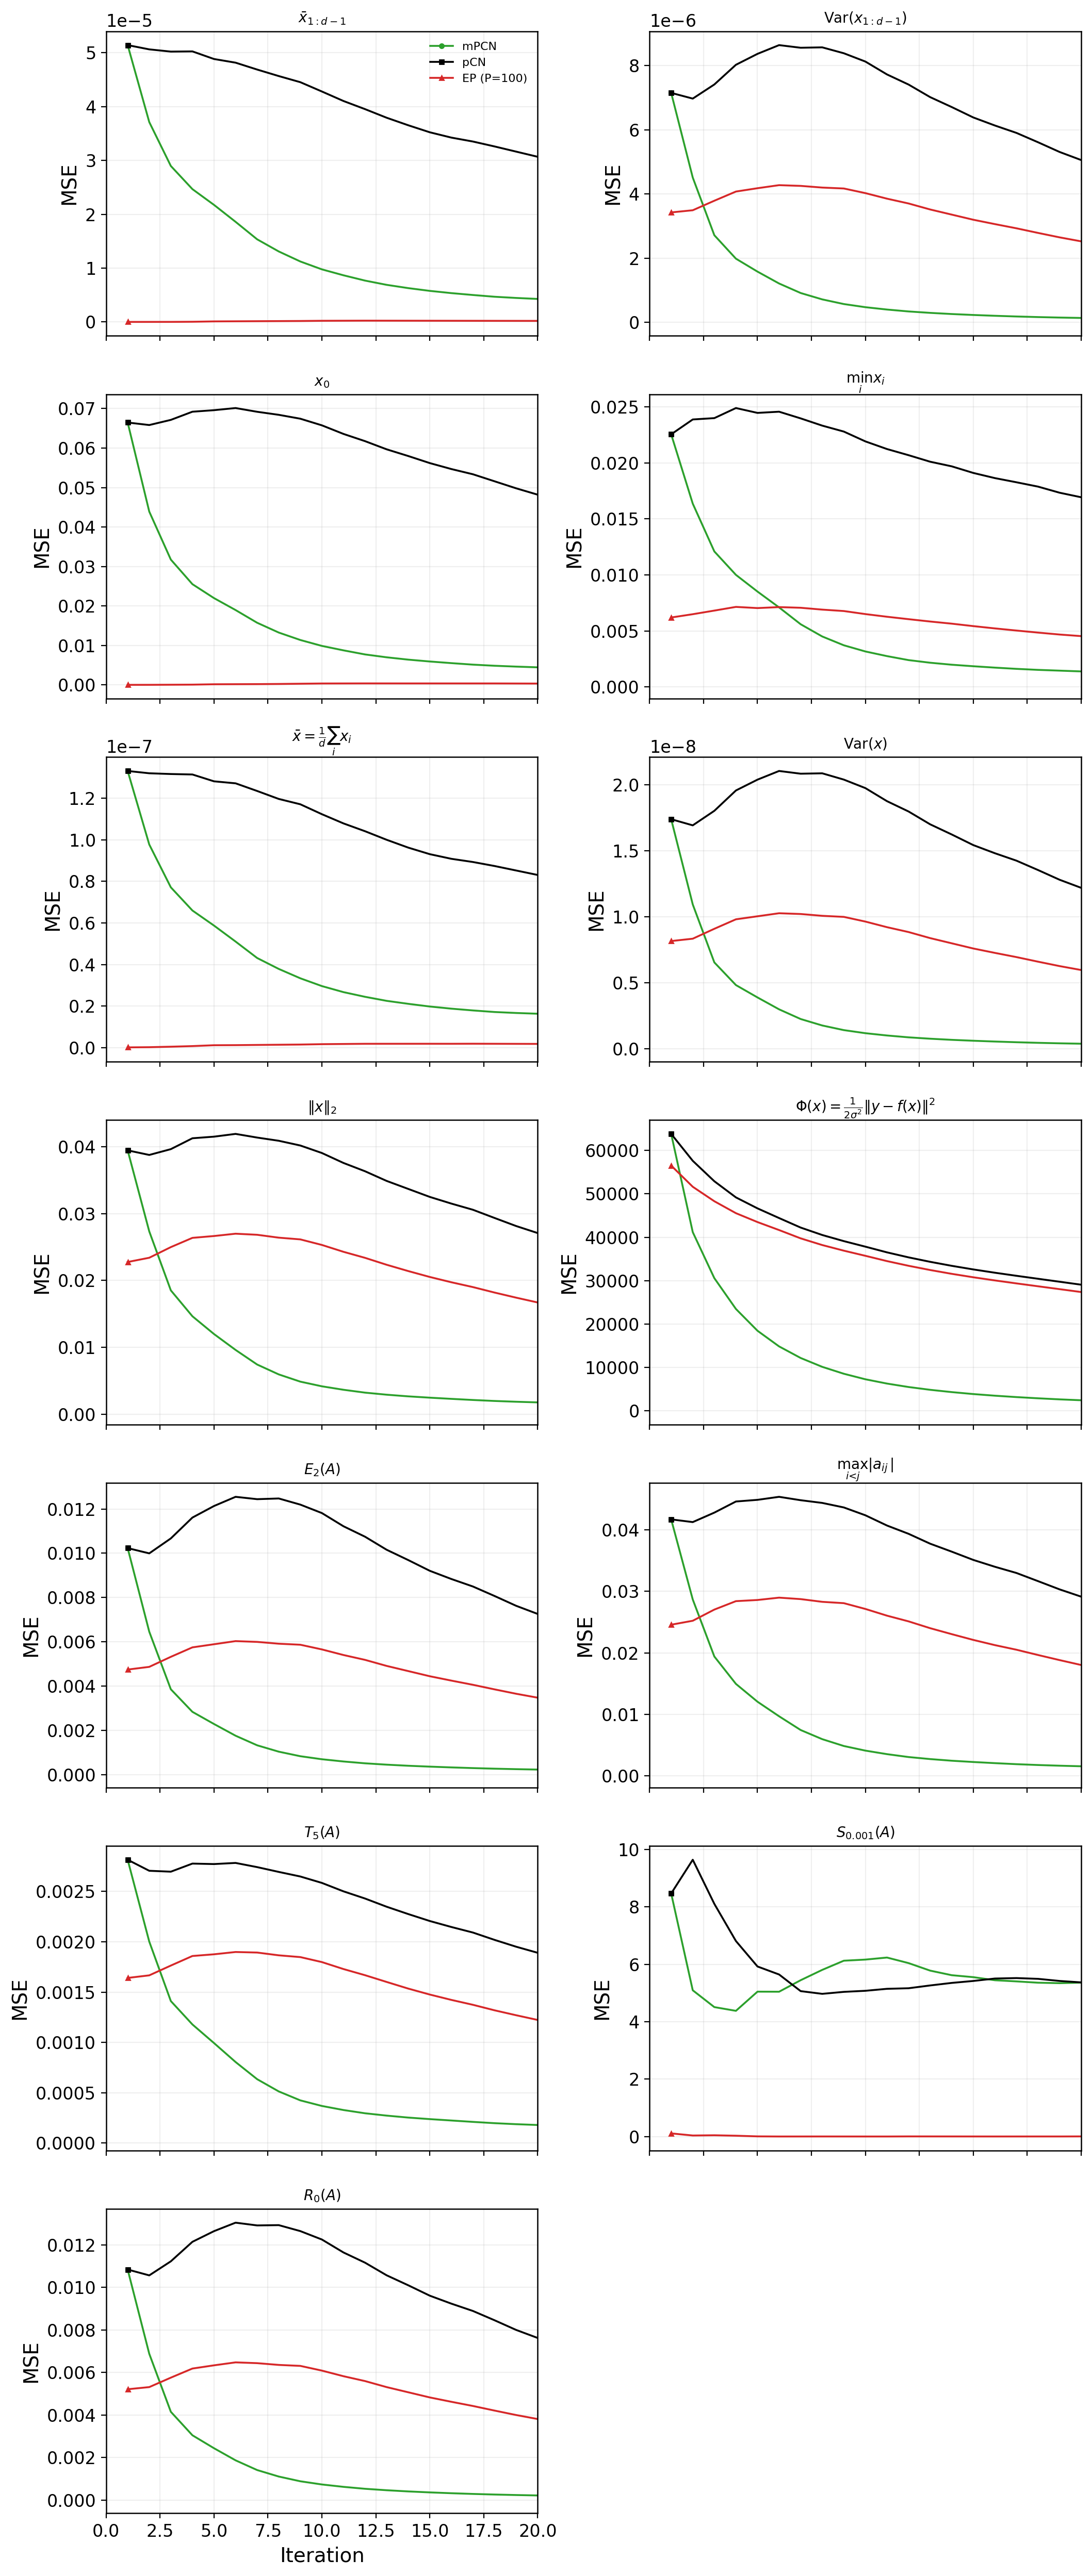

In [25]:
# Running MSE: plot series
apply_pub_style()

mpcn_color = '#2ca02c'
pcn_color = 'black'
ep_color = '#d62728'
mpcn_marker = 'o'
pcn_marker = 's'
ep_marker = '^'
markevery = max(1, len(iter_grid) // 10)
mpcn_line_kwargs = {
    'color': mpcn_color,
    'marker': mpcn_marker,
    'markersize': 3,
    'markevery': markevery,
    'linewidth': 1.3,
}
pcn_line_kwargs = {
    'color': pcn_color,
    'marker': pcn_marker,
    'markersize': 3,
    'markevery': markevery,
    'linewidth': 1.3,
}
ep_line_kwargs = {
    'color': ep_color,
    'marker': ep_marker,
    'markersize': 3,
    'markevery': markevery,
    'linewidth': 1.3,
}

plot_defs = mse_plot_defs
n_obs = len(plot_defs)
nrows = int(np.ceil(n_obs / 2))
fig, axes = plt.subplots(nrows, 2, figsize=(10.8, 3.6 * nrows), sharex=True)
if nrows == 1:
    axes = np.array([axes])

for idx, obs in enumerate(plot_defs):
    result = mse_results[obs.name]
    row_idx = idx // 2
    col_idx = idx % 2
    ax = axes[row_idx, col_idx]
    ax.plot(iter_grid, result['mpcn_mse'], label='mPCN', **mpcn_line_kwargs)
    ax.plot(iter_grid, result['pcn_mse'], label='pCN', **pcn_line_kwargs)
    if result['ep_mse'] is not None:
        ax.plot(iter_grid, result['ep_mse'], label=f'EP (P={effective_P})', **ep_line_kwargs)
    ax.set_title(obs.label, fontsize=10)
    ax.set_ylabel('MSE')
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(frameon=False, fontsize=8)

if n_obs % 2 == 1:
    axes[-1, 1].set_visible(False)

for ax in axes[-1, :]:
    if ax.get_visible():
        ax.set_xlabel('Iteration')
        ax.set_xlim(0, 20)

fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_mse_timeseries_observables_rho{rho_tag}.png',
    bbox_inches='tight',
)
plt.show()

## Running MSE: calculation details

This section summarizes the calculations used for the running MSE plots.

**Observables (by ID)**
1. $\bar{x}_{1:d-1}$: mean of the first $d-1$ elements of the parameter vector.
2. $\mathrm{Var}(x_{1:d-1})$: variance of the first $d-1$ elements.
3. $x_0$: first component.
4. $\min_i x_i$: minimum over all components.
5. $\bar{x}=\frac{1}{d}\sum_i x_i$: mean over all components.
6. $\mathrm{Var}(x)$: variance over all components.
7. $\|x\|_2$: Euclidean norm.
8. $\Phi(x)=\frac{1}{2\sigma^2}\|y-f(x)\|^2$: potential.

**Running means**
For a chain $\{X_t\}_{t=1}^T$ and observable $\varphi$, the running mean is
$$\bar{\varphi}_t=\frac{1}{t}\sum_{s=1}^t \varphi(X_s).$$
For EP, we first average over the $P$ parallel chains at each iteration,
$$\tilde{\varphi}_t^{\mathrm{EP}}=\frac{1}{P}\sum_{p=1}^P \varphi(X_{t,p}),$$
then compute the running mean over iterations,
$$\bar{\varphi}_t^{\mathrm{EP}}=\frac{1}{t}\sum_{s=1}^t \tilde{\varphi}_s^{\mathrm{EP}}.$$
By linearity, this is equivalent to averaging the per-chain running means at each $t$.

**Reference target**
Targets are posterior means estimated from long mPCN chains after burn-in $10{,}000$:
$$\mu_\varphi=\frac{1}{K}\sum_{k=1}^K \Big(\frac{1}{T-10{,}000}\sum_{t=10{,}001}^T \varphi(X_t^{(k)})\Big).$$

**Running MSE**
At each iteration $t$, the MSE is averaged across chains (or EP groups):
$$\mathrm{MSE}_t=\frac{1}{K}\sum_{k=1}^K\big(\bar{\varphi}_t^{(k)}-\mu_\varphi\big)^2.$$

**Plot selection**
Use the `mse_observable_ids` list in the running-MSE section to control which IDs are shown. The defaults exclude IDs 5 and 6 (mean and variance over all components).